# ✈️ 항공권 데이터 생성
**프로젝트**: 날짜 유연 여행자를 위한 최저 총비용 날짜 추천 시스템  
**데이터 범위**: 2026년 1월 1일 ~ 12월 31일  
**출발지**: 인천(ICN)  
**목적지**: 일본 주요 도시  

## 0. 라이브러리 설치 및 임포트

In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
import random
import os

random.seed(42)
np.random.seed(42)

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 1. 항공사 및 노선 정의

In [2]:
# 항공사 및 노선 정보
AIRLINES = {
    # 한국 FSC
    '대한항공': {
        'type': 'FSC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로', '나고야',
                   '오키나와', '가고시마', '니가타', '아오모리', '고마쓰', '오카야마']
    },
    '아시아나항공': {
        'type': 'FSC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로', '나고야',
                   '오키나와', '센다이', '미야자키', '구마모토']
    },
    # 한국 LCC
    '제주항공': {
        'type': 'LCC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로', '나고야',
                   '오키나와', '마쓰야마', '시즈오카', '히로시마', '오이타', '하코다테', '고베']
    },
    '진에어': {
        'type': 'LCC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로', '나고야',
                   '오키나와', '기타큐슈', '다카마쓰']
    },
    '티웨이항공': {
        'type': 'LCC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로', '나고야',
                   '오키나와', '구마모토', '사가', '오이타']
    },
    '에어부산': {
        'type': 'LCC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '삿포로']
    },
    '에어서울': {
        'type': 'LCC',
        'country': 'KR',
        'routes': ['도쿄(나리타)', '오사카(간사이)', '후쿠오카', '다카마쓰', '요나고']
    },
    # 일본 FSC
    'JAL': {
        'type': 'FSC',
        'country': 'JP',
        'routes': ['도쿄(나리타)']
    },
    'ANA': {
        'type': 'FSC',
        'country': 'JP',
        'routes': ['도쿄(나리타)']
    },
    # 일본 LCC
    '피치항공': {
        'type': 'LCC',
        'country': 'JP',
        'routes': ['도쿄(나리타)', '도쿄(하네다)', '오사카(간사이)', '오키나와']
    },
}

print(f'✅ 항공사 수: {len(AIRLINES)}개')
print(f'✅ 총 노선 수: {sum(len(v["routes"]) for v in AIRLINES.values())}개 (중복 포함)')

✅ 항공사 수: 10개
✅ 총 노선 수: 64개 (중복 포함)


## 2. 가격 계수 정의

In [3]:
# 노선별 기준 가격 (편도, 원화)
ROUTE_BASE_PRICE = {
    # 비싼 노선
    '도쿄(하네다)':   260000,  # 피치항공 단독, 도심 접근성
    '삿포로':         220000,  # 거리 가장 길고 겨울 수요 폭발
    '니가타':         210000,  # FSC 단독
    '아오모리':       210000,  # FSC 단독
    '센다이':         200000,  # FSC 단독
    '미야자키':       200000,  # FSC 단독
    '고마쓰':         200000,  # FSC 단독
    '가고시마':       190000,  # FSC 단독
    '오카야마':       190000,  # FSC 단독
    '구마모토':       185000,
    # 중간 노선
    '도쿄(나리타)':   170000,
    '나고야':         165000,
    '하코다테':       180000,
    '시즈오카':       160000,
    '오키나와':       155000,
    '고베':           150000,
    # 싼 노선
    '오사카(간사이)': 130000,  # LCC 경쟁 치열
    '후쿠오카':       120000,  # LCC 경쟁 치열
    '히로시마':       125000,
    '기타큐슈':       120000,
    '다카마쓰':       115000,  # LCC 프로모션
    '마쓰야마':       115000,  # LCC 프로모션
    '오이타':         115000,  # LCC 프로모션
    '사가':           110000,  # LCC 지자체 보조금
    '요나고':         110000,
}

# 항공사 타입별 가격 계수
AIRLINE_TYPE_MULTIPLIER = {
    'FSC': 1.6,
    'LCC': 1.0,
}

# 성수기 정의 (월, 일) 기반
def get_season_multiplier(d):
    month = d.month
    day   = d.day

    # 초성수기: 여름 휴가 절정 + 설/추석
    if month == 8 and 1 <= day <= 15:        return 2.2  # 여름 절정
    if month == 7 and 20 <= day <= 31:       return 2.0  # 여름 성수기
    if month == 12 and 24 <= day <= 31:      return 2.0  # 크리스마스·연말
    if month == 1  and 1  <= day <= 5:       return 2.0  # 신년

    # 성수기
    if month in [7, 8]:                      return 1.8  # 여름 방학
    if month == 3 and 20 <= day <= 31:       return 1.6  # 벚꽃
    if month == 4 and 1  <= day <= 15:       return 1.6  # 벚꽃
    if month == 4 and 28 <= day <= 30:       return 1.7  # 골든위크 직전
    if month == 5 and 1  <= day <= 6:        return 1.9  # 골든위크
    if month == 12 and 20 <= day <= 23:      return 1.5  # 겨울방학 시작

    # 준성수기
    if month in [3, 4]:                      return 1.3
    if month in [1, 2]:                      return 1.2  # 삿포로 겨울
    if month in [10, 11]:                    return 1.2  # 단풍

    # 비수기
    if month == 6:                           return 0.85  # 장마
    if month == 9:                           return 0.90  # 태풍

    return 1.0  # 평시

# 삿포로 겨울 추가 보정
def get_sapporo_multiplier(d):
    month = d.month
    if month in [12, 1, 2]:   return 1.5   # 눈축제·스키
    if month in [3]:          return 1.2
    return 1.0

# 하네다 추가 보정 (피치항공 단독)
HANEDA_PREMIUM = 1.2

print('✅ 가격 계수 정의 완료')

✅ 가격 계수 정의 완료


## 3. flights 데이터 생성

In [4]:
start_date = date(2026, 1, 1)
end_date   = date(2026, 12, 31)
date_range = [start_date + timedelta(days=i)
              for i in range((end_date - start_date).days + 1)]

records = []
flight_id = 1

for airline_name, info in AIRLINES.items():
    airline_type = info['type']
    airline_country = info['country']

    for destination in info['routes']:
        base_price = ROUTE_BASE_PRICE.get(destination, 150000)

        for d in date_range:
            season_mult  = get_season_multiplier(d)
            airline_mult = AIRLINE_TYPE_MULTIPLIER[airline_type]
            sapporo_mult = get_sapporo_multiplier(d) if destination == '삿포로' else 1.0
            haneda_mult  = HANEDA_PREMIUM if destination == '도쿄(하네다)' else 1.0
            noise        = np.random.uniform(0.90, 1.10)

            price = int(
                base_price
                * airline_mult
                * season_mult
                * sapporo_mult
                * haneda_mult
                * noise
            )

            is_weekend     = d.weekday() >= 5          # 토(5), 일(6)
            is_peak_season = season_mult >= 1.5

            records.append({
                'flight_id':       flight_id,
                'departure_date':  d.strftime('%Y-%m-%d'),
                'airline_name':    airline_name,
                'airline_type':    airline_type,
                'airline_country': airline_country,
                'destination':     destination,
                'price':           price,
                'is_weekend':      is_weekend,
                'is_peak_season':  is_peak_season,
                'season_multiplier': round(season_mult, 2),
                'day_of_week':     d.strftime('%A'),
                'month':           d.month,
            })
            flight_id += 1

flights_df = pd.DataFrame(records)
print(f'✅ flights 데이터 생성 완료: {len(flights_df):,}행')
flights_df.head(3)

✅ flights 데이터 생성 완료: 23,360행


,flight_id,departure_date,airline_name,airline_type,airline_country,destination,price,is_weekend,is_peak_season,season_multiplier,day_of_week,month
0,1,2026-01-01,대한항공,FSC,KR,도쿄(나리타),530349,False,True,2.0,Thursday,1
1,2,2026-01-02,대한항공,FSC,KR,도쿄(나리타),593037,False,True,2.0,Friday,1
2,3,2026-01-03,대한항공,FSC,KR,도쿄(나리타),569240,True,True,2.0,Saturday,1


## 4. hotels 데이터 생성

In [5]:
# 지역별 1박 평균 호텔 가격 (원화)
HOTEL_BASE_PRICE = {
    '도쿄(나리타)':   120000,
    '도쿄(하네다)':   130000,
    '오사카(간사이)': 100000,
    '후쿠오카':        90000,
    '삿포로':          95000,
    '나고야':          90000,
    '오키나와':       105000,
    '가고시마':        80000,
    '니가타':          75000,
    '아오모리':        75000,
    '센다이':          80000,
    '미야자키':        78000,
    '고마쓰':          75000,
    '오카야마':        78000,
    '구마모토':        80000,
    '마쓰야마':        75000,
    '시즈오카':        80000,
    '히로시마':        85000,
    '오이타':          75000,
    '하코다테':        85000,
    '고베':            90000,
    '기타큐슈':        75000,
    '다카마쓰':        75000,
    '사가':            70000,
    '요나고':          70000,
}

hotel_records = []
hotel_id = 1

for destination, base_price in HOTEL_BASE_PRICE.items():
    for d in date_range:
        season_mult  = get_season_multiplier(d)
        # 삿포로 겨울 호텔 추가 보정
        sapporo_mult = get_sapporo_multiplier(d) if destination == '삿포로' else 1.0
        # 주말 호텔 10% 추가
        weekend_mult = 1.10 if d.weekday() >= 5 else 1.0
        noise        = np.random.uniform(0.90, 1.10)

        price_per_night = int(
            base_price
            * season_mult
            * sapporo_mult
            * weekend_mult
            * noise
        )

        hotel_records.append({
            'hotel_id':         hotel_id,
            'date':             d.strftime('%Y-%m-%d'),
            'destination':      destination,
            'avg_price_per_night': price_per_night,
            'is_weekend':       d.weekday() >= 5,
            'is_peak_season':   season_mult >= 1.5,
            'month':            d.month,
        })
        hotel_id += 1

hotels_df = pd.DataFrame(hotel_records)
print(f'✅ hotels 데이터 생성 완료: {len(hotels_df):,}행')
hotels_df.head(3)

✅ hotels 데이터 생성 완료: 9,125행


,hotel_id,date,destination,avg_price_per_night,is_weekend,is_peak_season,month
0,1,2026-01-01,도쿄(나리타),250900,False,True,1
1,2,2026-01-02,도쿄(나리타),216733,False,True,1
2,3,2026-01-03,도쿄(나리타),249569,True,True,1


## 5. transportation 데이터 생성

In [6]:
# 공항 → 도심 교통 정보 (지역별 고정값)
TRANSPORT_INFO = {
    '도쿄(나리타)':   [('나리타 익스프레스', 36000, 60), ('리무진버스', 18000, 90),  ('공항버스(저가)', 12000, 120)],
    '도쿄(하네다)':   [('도쿄 모노레일',     12000, 25), ('케이큐선',     9000,  30),  ('리무진버스',     15000, 40)],
    '오사카(간사이)': [('하루카 특급',        20000, 75), ('리무진버스',   12000, 70),  ('난카이 래피트', 15000, 45)],
    '후쿠오카':       [('지하철',              5000, 10), ('버스',          4000, 25),  ('택시',          15000, 20)],
    '삿포로':         [('JR 쾌속 에어포트',   11000, 38), ('리무진버스',   10000, 55)],
    '나고야':         [('메이테츠 특급',      12000, 28), ('리무진버스',    9000, 45)],
    '오키나와':       [('리무진버스',          9000, 55), ('택시',         20000, 40),  ('렌터카',        25000, 30)],
    '가고시마':       [('리무진버스',          7000, 40), ('시영버스',      5000, 50)],
    '니가타':         [('리무진버스',          8000, 30), ('택시',         15000, 25)],
    '아오모리':       [('리무진버스',          7000, 35), ('택시',         14000, 30)],
    '센다이':         [('리무진버스',          9000, 45), ('지하철',        6000, 30)],
    '미야자키':       [('리무진버스',          7000, 30), ('택시',         15000, 20)],
    '고마쓰':         [('리무진버스',          6000, 35), ('택시',         13000, 25)],
    '오카야마':       [('리무진버스',          7000, 30), ('택시',         14000, 20)],
    '구마모토':       [('리무진버스',          8000, 40), ('택시',         16000, 30)],
    '마쓰야마':       [('리무진버스',          6000, 30), ('택시',         13000, 20)],
    '시즈오카':       [('리무진버스',          7000, 30), ('택시',         14000, 20)],
    '히로시마':       [('리무진버스',          9000, 45), ('아스트램라인',  5000, 40)],
    '오이타':         [('리무진버스',          7000, 40), ('택시',         14000, 30)],
    '하코다테':       [('리무진버스',          8000, 20), ('택시',         12000, 15)],
    '고베':           [('포트라이너',          5000, 18), ('리무진버스',    8000, 30)],
    '기타큐슈':       [('모노레일',            4000, 10), ('버스',          3500, 20)],
    '다카마쓰':       [('리무진버스',          6000, 30), ('택시',         12000, 20)],
    '사가':           [('리무진버스',          5000, 35), ('택시',         13000, 25)],
    '요나고':         [('리무진버스',          5000, 25), ('택시',         11000, 15)],
}

transport_records = []
transport_id = 1

for destination, options in TRANSPORT_INFO.items():
    for transport_type, price, duration_min in options:
        transport_records.append({
            'transport_id':    transport_id,
            'destination':     destination,
            'transport_type':  transport_type,
            'price':           price,
            'duration_min':    duration_min,
            'airport_to_city': True,
        })
        transport_id += 1

transportation_df = pd.DataFrame(transport_records)
print(f'✅ transportation 데이터 생성 완료: {len(transportation_df):,}행')
transportation_df.head(5)

✅ transportation 데이터 생성 완료: 55행


,transport_id,destination,transport_type,price,duration_min,airport_to_city
0,1,도쿄(나리타),나리타 익스프레스,36000,60,True
1,2,도쿄(나리타),리무진버스,18000,90,True
2,3,도쿄(나리타),공항버스(저가),12000,120,True
3,4,도쿄(하네다),도쿄 모노레일,12000,25,True
4,5,도쿄(하네다),케이큐선,9000,30,True


## 6. 데이터 검증

In [7]:
print('=' * 50)
print('📊 데이터 검증')
print('=' * 50)

print(f'\n[flights]')
print(f'  총 행 수     : {len(flights_df):,}')
print(f'  항공사 수    : {flights_df["airline_name"].nunique()}')
print(f'  목적지 수    : {flights_df["destination"].nunique()}')
print(f'  가격 범위    : {flights_df["price"].min():,}원 ~ {flights_df["price"].max():,}원')
print(f'  평균 가격    : {flights_df["price"].mean():,.0f}원')

print(f'\n[FSC vs LCC 평균 가격]')
print(flights_df.groupby('airline_type')['price'].mean().apply(lambda x: f'{x:,.0f}원'))

print(f'\n[노선별 평균 가격 Top 5 (비싼 순)]')
route_price = flights_df.groupby('destination')['price'].mean().sort_values(ascending=False)
for dest, price in route_price.head(5).items():
    print(f'  {dest}: {price:,.0f}원')

print(f'\n[노선별 평균 가격 Top 5 (싼 순)]')
for dest, price in route_price.tail(5).items():
    print(f'  {dest}: {price:,.0f}원')

print(f'\n[hotels]')
print(f'  총 행 수     : {len(hotels_df):,}')
print(f'  가격 범위    : {hotels_df["avg_price_per_night"].min():,}원 ~ {hotels_df["avg_price_per_night"].max():,}원')

print(f'\n[transportation]')
print(f'  총 행 수     : {len(transportation_df):,}')
print(f'  목적지 수    : {transportation_df["destination"].nunique()}')

📊 데이터 검증

[flights]
  총 행 수     : 23,360
  항공사 수    : 10
  목적지 수    : 25
  가격 범위    : 84,171원 ~ 1,155,279원
  평균 가격    : 266,433원

[FSC vs LCC 평균 가격]
airline_type
FSC    378,398원
LCC    207,784원
Name: price, dtype: object

[노선별 평균 가격 Top 5 (비싼 순)]
  아오모리: 448,038원
  니가타: 446,783원
  고마쓰: 426,981원
  센다이: 426,770원
  미야자키: 425,360원

[노선별 평균 가격 Top 5 (싼 순)]
  다카마쓰: 153,642원
  오이타: 153,124원
  마쓰야마: 152,925원
  요나고: 146,919원
  사가: 146,821원

[hotels]
  총 행 수     : 9,125
  가격 범위    : 53,673원 ~ 335,045원

[transportation]
  총 행 수     : 55
  목적지 수    : 25


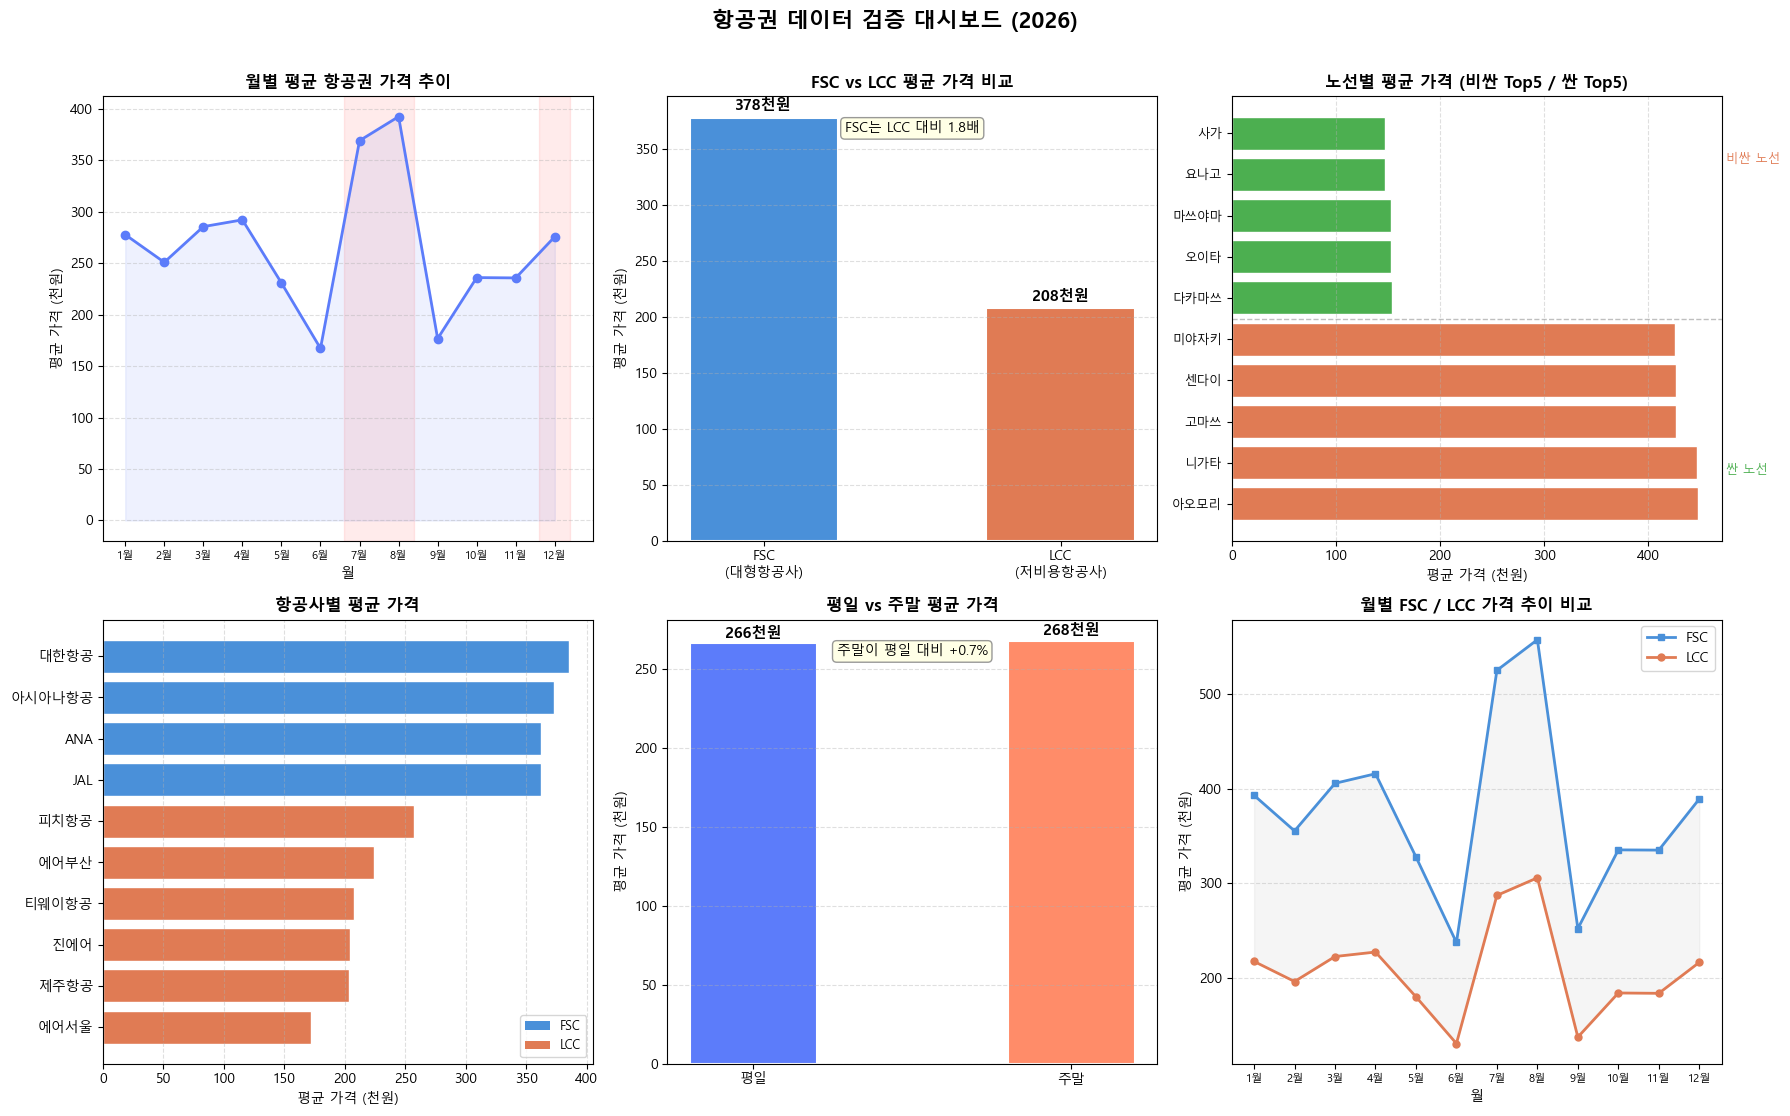

✅ 시각화 저장 완료: data/viz_validation.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 코랩에서 한글 폰트 없을 시 아래 실행 후 런타임 재시작
# !apt-get install -y fonts-nanum > /dev/null
# !fc-cache -fv > /dev/null

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('항공권 데이터 검증 대시보드 (2026)', fontsize=16, fontweight='bold', y=1.01)

COLORS_FSC = '#4A90D9'
COLORS_LCC = '#E07B54'
COLOR_MAIN = '#5C7CFA'

# ─────────────────────────────────────────────
# 차트 1: 월별 평균 항공권 가격 추이
# ─────────────────────────────────────────────
ax1 = axes[0, 0]
monthly_avg = flights_df.groupby('month')['price'].mean()
months_label = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

ax1.plot(monthly_avg.index, monthly_avg.values / 1000, marker='o', color=COLOR_MAIN, linewidth=2, markersize=6)
ax1.fill_between(monthly_avg.index, monthly_avg.values / 1000, alpha=0.1, color=COLOR_MAIN)
ax1.set_title('월별 평균 항공권 가격 추이', fontweight='bold')
ax1.set_xlabel('월')
ax1.set_ylabel('평균 가격 (천원)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months_label, fontsize=8)

# 성수기 구간 음영
for peak_range in [(7, 8), (12, 12)]:
    ax1.axvspan(peak_range[0] - 0.4, peak_range[1] + 0.4, alpha=0.08, color='red', label='성수기')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ─────────────────────────────────────────────
# 차트 2: FSC vs LCC 평균 가격 비교
# ─────────────────────────────────────────────
ax2 = axes[0, 1]
fsc_lcc = flights_df.groupby('airline_type')['price'].mean()
bars = ax2.bar(['FSC\n(대형항공사)', 'LCC\n(저비용항공사)'],
               fsc_lcc.values / 1000,
               color=[COLORS_FSC, COLORS_LCC],
               width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, fsc_lcc.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 3,
             f'{val/1000:,.0f}천원',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# FSC/LCC 배율 표시
ratio = fsc_lcc['FSC'] / fsc_lcc['LCC']
ax2.text(0.5, 0.92, f'FSC는 LCC 대비 {ratio:.1f}배',
         transform=ax2.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

ax2.set_title('FSC vs LCC 평균 가격 비교', fontweight='bold')
ax2.set_ylabel('평균 가격 (천원)')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# ─────────────────────────────────────────────
# 차트 3: 노선별 평균 가격 (비싼 Top5 + 싼 Top5)
# ─────────────────────────────────────────────
ax3 = axes[0, 2]
route_price = flights_df.groupby('destination')['price'].mean().sort_values(ascending=False)
top5    = route_price.head(5)
bottom5 = route_price.tail(5)
combined = pd.concat([top5, bottom5])

colors_route = ['#E07B54'] * 5 + ['#4CAF50'] * 5
bars = ax3.barh(range(len(combined)), combined.values / 1000,
                color=colors_route, edgecolor='white')

ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels(combined.index, fontsize=9)
ax3.set_title('노선별 평균 가격 (비싼 Top5 / 싼 Top5)', fontweight='bold')
ax3.set_xlabel('평균 가격 (천원)')
ax3.axhline(y=4.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.text(1.01, 0.85, '비싼 노선', transform=ax3.transAxes, fontsize=9, color='#E07B54')
ax3.text(1.01, 0.15, '싼 노선',  transform=ax3.transAxes, fontsize=9, color='#4CAF50')
ax3.grid(axis='x', linestyle='--', alpha=0.4)

# ─────────────────────────────────────────────
# 차트 4: 항공사별 평균 가격
# ─────────────────────────────────────────────
ax4 = axes[1, 0]
airline_avg = (flights_df.groupby(['airline_name', 'airline_type'])['price']
               .mean()
               .reset_index()
               .sort_values('price', ascending=True))

colors_airline = [COLORS_FSC if t == 'FSC' else COLORS_LCC
                  for t in airline_avg['airline_type']]
bars = ax4.barh(airline_avg['airline_name'],
                airline_avg['price'] / 1000,
                color=colors_airline, edgecolor='white')

ax4.set_title('항공사별 평균 가격', fontweight='bold')
ax4.set_xlabel('평균 가격 (천원)')
ax4.grid(axis='x', linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS_FSC, label='FSC'),
                   Patch(facecolor=COLORS_LCC, label='LCC')]
ax4.legend(handles=legend_elements, loc='lower right', fontsize=9)

# ─────────────────────────────────────────────
# 차트 5: 평일 vs 주말 평균 가격
# ─────────────────────────────────────────────
ax5 = axes[1, 1]
weekend_avg = flights_df.groupby('is_weekend')['price'].mean()
labels = ['평일', '주말']
colors_wd = ['#5C7CFA', '#FF8C69']
bars = ax5.bar(labels, weekend_avg.values / 1000,
               color=colors_wd, width=0.4, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, weekend_avg.values):
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val/1000:,.0f}천원',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

diff = (weekend_avg[True] - weekend_avg[False]) / weekend_avg[False] * 100
ax5.text(0.5, 0.92, f'주말이 평일 대비 +{diff:.1f}%',
         transform=ax5.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

ax5.set_title('평일 vs 주말 평균 가격', fontweight='bold')
ax5.set_ylabel('평균 가격 (천원)')
ax5.grid(axis='y', linestyle='--', alpha=0.4)

# ─────────────────────────────────────────────
# 차트 6: 월별 FSC/LCC 가격 추이 비교
# ─────────────────────────────────────────────
ax6 = axes[1, 2]
monthly_type = flights_df.groupby(['month', 'airline_type'])['price'].mean().unstack()

ax6.plot(monthly_type.index, monthly_type['FSC'] / 1000,
         marker='s', color=COLORS_FSC, linewidth=2, markersize=5, label='FSC')
ax6.plot(monthly_type.index, monthly_type['LCC'] / 1000,
         marker='o', color=COLORS_LCC, linewidth=2, markersize=5, label='LCC')
ax6.fill_between(monthly_type.index, monthly_type['FSC'] / 1000,
                 monthly_type['LCC'] / 1000, alpha=0.08, color='gray')

ax6.set_title('월별 FSC / LCC 가격 추이 비교', fontweight='bold')
ax6.set_xlabel('월')
ax6.set_ylabel('평균 가격 (천원)')
ax6.set_xticks(range(1, 13))
ax6.set_xticklabels(months_label, fontsize=8)
ax6.legend()
ax6.grid(axis='y', linestyle='--', alpha=0.4)

# ─────────────────────────────────────────────
plt.tight_layout()
plt.savefig('data/viz_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 시각화 저장 완료: data/viz_validation.png')

## 7. CSV 저장

In [8]:
os.makedirs('data/raw', exist_ok=True)

flights_df.to_csv('data/raw/flights.csv', index=False, encoding='utf-8-sig')
hotels_df.to_csv('data/raw/hotels.csv', index=False, encoding='utf-8-sig')
transportation_df.to_csv('data/raw/transportation.csv', index=False, encoding='utf-8-sig')

print('✅ CSV 저장 완료!')
print(f'  data/raw/flights.csv        : {len(flights_df):,}행')
print(f'  data/raw/hotels.csv         : {len(hotels_df):,}행')
print(f'  data/raw/transportation.csv : {len(transportation_df):,}행')

✅ CSV 저장 완료!
  data/raw/flights.csv        : 23,360행
  data/raw/hotels.csv         : 9,125행
  data/raw/transportation.csv : 55행


In [12]:
# 1. 설치된 한글 폰트 확인
import matplotlib.font_manager as fm
korean_fonts = [f.name for f in fm.fontManager.ttflist if any(k in f.name for k in ['Nanum', 'Malgun', 'Gothic', 'Gulim'])]
print(korean_fonts)

['HYGothic-Extra', 'Franklin Gothic Demi', 'Copperplate Gothic Bold', 'Century Gothic', 'Franklin Gothic Medium', 'Franklin Gothic Book', 'New Gulim', 'Franklin Gothic Demi', 'Franklin Gothic Demi Cond', 'Century Gothic', 'HYGothic-Medium', 'Copperplate Gothic Light', 'Yu Gothic', 'Malgun Gothic', 'Franklin Gothic Medium Cond', 'Malgun Gothic', 'MS Gothic', 'Franklin Gothic Heavy', 'Franklin Gothic Book', 'Yu Gothic', 'Franklin Gothic Medium', 'Yu Gothic', 'Century Gothic', 'Malgun Gothic', 'Yu Gothic', 'Franklin Gothic Heavy', 'Showcard Gothic', 'Century Gothic', 'Gulim']
